<a href="https://colab.research.google.com/github/naminipla1920-ui/Private/blob/main/Anomaly_detection_in_SL_bus_delays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AH2179 Final Project: Anomaly detection in SL bus delays


## Section 0: Setup and fast load

Loads pre-computed data and trained models from Drive.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from google.colab import drive

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Project AI in Transportation'
ALERTS_PATH = f"{BASE}/alerts_results"
LINE_ID = '9011001050700000'

sns.set()

Mounted at /content/drive


Load data (features and incidents)

In [3]:
# Cleaned line data with features (Section 4)
clean = pd.read_csv(f"{ALERTS_PATH}/line_{LINE_ID}_features.csv")

# Reconstructed service-alert incidents (from Section 1, for validation later)
route_incidents = pd.read_csv(f"{ALERTS_PATH}/route_incidents.csv")

print("clean:", clean.shape, ", incidents:", route_incidents.shape)

clean: (418125, 30) , incidents: (5161, 8)


Rebuild split and scaling

In [4]:
features = ['hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos',
            'stop_sequence', 'dist_traveled', 'upstream_delay']
target = 'observed_arrival_delay'

model_df = clean.dropna(subset=['upstream_delay']).copy()
model_df['date'] = pd.to_datetime(model_df['date'])
model_df = model_df.sort_values(['date','trip_id','stop_sequence']).reset_index(drop=True)

# Chronological 3-way split
train_df = model_df[model_df['date'] < '2024-10-01']
val_df   = model_df[(model_df['date'] >= '2024-10-01') & (model_df['date'] < '2024-11-01')]
test_df  = model_df[model_df['date'] >= '2024-11-01']

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

# Scaling (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (290947, 9) | Val: (34598, 9) | Test: (64141, 9)


Load trained models

In [5]:
import joblib
from tensorflow import keras

# Random Forest (best model)
best_rf = joblib.load(f"{ALERTS_PATH}/rf_model.pkl")

# Neural networks (for comparison)
model_nn_512 = keras.models.load_model(f"{ALERTS_PATH}/nn_model_512.keras")
model_nn_256 = keras.models.load_model(f"{ALERTS_PATH}/nn_model_256.keras")

print("Models loaded")

Models loaded


## Section 1: Line selection:
Choose one bus line to develop the anomaly-detection
pipeline on, based on three criteria: enough operational data to learn normal behaviour, enough real disruption incidents to validate against, and a good share of incidents with a specified stop

### Data loading and Service Alerts preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

BASE = '/content'
MONTHS = ['202401', '202402', '202403', '202404', '202405', '202406', '202407',
          '202408', '202409', '202410', '202411', '202412']
MODE_NAMES = {700: 'BUS', 401: 'METRO', 106: 'RAIL', 900: 'TRAM', 1000: 'SHIP'}

### Static GTFS Regional Static reference data and Service Alerts

In [ ]:
routes = pd.read_csv(f'{BASE}/routes.csv', sep=';')
stops  = pd.read_csv(f'{BASE}/stops.csv',  sep=';')
trips  = pd.read_csv(f'{BASE}/trips.csv',  sep=';')

# Service Alerts
alerts = pd.read_parquet(f'{BASE}/service_alerts_2024.parquet')

print("routes:", routes.shape)
print("stops :", stops.shape)
print("trips :", trips.shape)
print("alerts:", alerts.shape)

routes: (653, 5)
stops : (21661, 7)
trips : (308318, 5)
alerts: (1972779, 13)


### 1.1 ServiceAlerts: incident reconstruction
The raw feed has one row per alert, route and stop. A single disruption is duplicated across affected entities and re-reported over time under different ids.


In [ ]:
alerts_real = alerts[alerts['route_id'] != '-1'].copy()

by_id_route = (alerts_real
               .groupby(['id', 'route_id'])
               .agg(start=('start', 'first'),
                    end=('end', 'first'),
                    cause=('cause', 'first'),
                    n_stops=('stop_id', lambda s: int((s != -1).sum())))
               .reset_index())

# Merge overlapping windows within each route
GAP_TOL = pd.Timedelta(0)

def merge_windows(g):
    g = g.sort_values('start')
    out, cur = [], None
    for _, r in g.iterrows():
        if cur is None:
            cur = r.to_dict(); cur['n_ids'] = 1; continue
        if r['start'] <= cur['end'] + GAP_TOL:
            cur['end']    = max(cur['end'], r['end'])
            cur['n_ids']  += 1
            cur['n_stops'] = max(cur['n_stops'], r['n_stops'])
            if cur['cause'] != r['cause']:
                cur['cause'] = -99
        else:
            out.append(cur); cur = r.to_dict(); cur['n_ids'] = 1
    if cur is not None:
        out.append(cur)
    return pd.DataFrame(out)

route_incidents = (by_id_route
                   .groupby('route_id', group_keys=False)[by_id_route.columns.tolist()]
                   .apply(merge_windows)
                   .reset_index(drop=True))

route_incidents['duration_min'] = (
    (route_incidents['end'] - route_incidents['start']).dt.total_seconds() / 60
)

print("Raw rows (real route):", len(alerts_real))
print("id x route:           ", len(by_id_route))
print("Real incidents:       ", len(route_incidents))

Raw rows (real route): 40314
id x route:            9760
Real incidents:        5161


### 1.2 Event volume per route


In [ ]:
# Event volume per route
# Read each monthly file in chunks (only route_id) and accumulate counts.
months = [f'202401', '202402', '202403', '202404', '202405', '202406',
          '202407', '202408', '202409', '202410', '202411', '202412']

counts = Counter()
for m in months:
    path = f'{BASE}/gtfs_rt_{m}.csv.gz'
    for chunk in pd.read_csv(path, sep=';', usecols=['route_id'],
                             dtype={'route_id': str}, chunksize=500_000):
        counts.update(chunk['route_id'].value_counts().to_dict())
    print(f"{m} done")

events_per_route = (pd.DataFrame(counts.items(),
                                 columns=['route_id', 'n_events'])
                    .sort_values('n_events', ascending=False))
print("Distinct routes (full year):", len(events_per_route))

202401 done
202402 done
202403 done
202404 done
202405 done
202406 done
202407 done
202408 done
202409 done
202410 done
202411 done
202412 done
Distinct routes (full year): 649


### 1.3 Candidate lines per mode

In [ ]:
def candidates_by_mode(route_type, incidents_table, events_table):
    """Line-selection table for ONE transport mode."""
    inc = (incidents_table
           .groupby('route_id')
           .agg(n_incidents=('start', 'count'),
                n_inc_with_stop=('n_stops', lambda s: int((s > 0).sum())))
           .reset_index())
    mode_routes = routes[routes['route_type'] == route_type]
    c = (inc.merge(mode_routes[['route_id', 'route_short_name']],
                   on='route_id', how='inner')
            .merge(events_table, on='route_id', how='left'))
    # Drop routes with no events and service variants
    c = c[c['n_events'].notna() &
          ~c['route_short_name'].str.contains(r'[A-Za-z]$', na=False, regex=True)]
    c['inc_per_1000_ev'] = (c['n_incidents'] / c['n_events'] * 1000).round(2)
    return c.sort_values('n_incidents', ascending=False)


# Ranking per mode (separate table for each)
for rt in [700, 401, 900, 106, 1000]:
    tbl = candidates_by_mode(rt, route_incidents, events_per_route)
    if len(tbl) == 0:
        continue
    print(f"=== {MODE_NAMES[rt]} ===")
    print(tbl.head(10).to_string(index=False), "\n")

=== BUS ===
        route_id  n_incidents  n_inc_with_stop route_short_name  n_events  inc_per_1000_ev
9011001017600000           43                2              176   1507010             0.03
9011001015200000           38               33              152     88673             0.43
9011001050700000           38               36              507    471625             0.08
9011001051400000           37               32              514   1178195             0.03
9011001017700000           36                0              177   1251270             0.03
9011001050600000           35               32              506    844580             0.04
9011001011200000           31               11              112    762226             0.04
9011001051500000           29               27              515   1183390             0.02
9011001050800000           29               29              508    122688             0.24
9011001017800000           28               15              178    962768     

###1.4 Selected line per mode
Pick the best candidate in each mode: most incidents with a specified stop

In [ ]:
def best_per_mode(route_type):
    tbl = candidates_by_mode(route_type, route_incidents, events_per_route)
    if len(tbl) == 0:
        return None
    return tbl.sort_values('n_inc_with_stop', ascending=False).iloc[0]

selected = []
for rt in [700, 401, 900, 106, 1000]:
    best = best_per_mode(rt)
    if best is not None:
        selected.append({'mode': MODE_NAMES[rt], **best[
            ['route_short_name', 'route_id', 'n_incidents',
             'n_inc_with_stop', 'n_events', 'inc_per_1000_ev']].to_dict()})

selected_lines = pd.DataFrame(selected)
print(selected_lines.to_string(index=False))

 mode route_short_name         route_id  n_incidents  n_inc_with_stop  n_events  inc_per_1000_ev
  BUS              507 9011001050700000           38               36  471625.0             0.08
METRO               19 9011001001900000           54               28 2692577.0             0.02
 TRAM                7 9011001000700000           94               84  987319.0             0.10
 SHIP               83 9011001008300000           20               17   58494.0             0.34


## Section 2: Load the selected line


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content'
ALERTS_PATH = '/content/drive/MyDrive/Project AI in Transportation/alerts_results'
LINE_ID = '9011001050700000'
MONTHS = ['202401','202402','202403','202404','202405','202406',
          '202407','202408','202409','202410','202411','202412']
COLS = ['date','LineNumber','route_id','direction_id','trip_id',
        'stop_sequence','dist_traveled','observed_stop_id','observed_StopAreaID',
        'scheduled_arrival_time_sfm','observed_arrival_time_sfm',
        'observed_arrival_delay','observed_arrival_uncertainty',
        'scheduled_departure_time_sfm','observed_departure_time_sfm',
        'observed_departure_delay','observed_departure_uncertainty',
        'tripupdates_and_gtfs_not_merged_within_service_id',
        'tripupdates_not_merged_with_stoptimes_or_trip']

def load_line(route_id, months=MONTHS, base=BASE, keep_cols=COLS):
    parts = []
    for m in months:
        path = f'{base}/gtfs_rt_{m}.csv.gz'
        for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
            sub = chunk[chunk['route_id'] == route_id]
            if keep_cols is not None:
                sub = sub[keep_cols]
            if len(sub):
                parts.append(sub)
        print(f"{m} done")
    df = pd.concat(parts, ignore_index=True)
    print(f"Loaded: {df.shape[0]:,} rows")
    return df

line_df = load_line(LINE_ID)
line_df.to_csv(f"{ALERTS_PATH}/line_{LINE_ID}_raw.csv", index=False)
print("Saved to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype opti

202401 done


/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype opti

202402 done


...

202410 done


/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype opti

202411 done


/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=';', dtype={'route_id': str}, chunksize=500_000):
/tmp/ipykernel_1132/1228295138.py:23: DtypeWarning: Columns (1) have mixed types. Specify dtype opti

202412 done
Loaded: 471,625 rows
Saved to Drive


In [ ]:
LINE_RAW_PATH = f"{ALERTS_PATH}/line_{LINE_ID}_raw.csv"
line_df = pd.read_csv(LINE_RAW_PATH)
print("Loaded from CSV:", line_df.shape)
line_df.head()

Loaded from CSV: (471625, 19)


,date,LineNumber,route_id,direction_id,trip_id,stop_sequence,dist_traveled,observed_stop_id,observed_StopAreaID,scheduled_arrival_time_sfm,observed_arrival_time_sfm,observed_arrival_delay,observed_arrival_uncertainty,scheduled_departure_time_sfm,observed_departure_time_sfm,observed_departure_delay,observed_departure_uncertainty,tripupdates_and_gtfs_not_merged_within_service_id,tripupdates_not_merged_with_stoptimes_or_trip
0,20240101,507,9011001050700000,0,14010000652468172,1,0.0,9022001050121001,9021001050121000,23520,22704.0,-816.0,0.0,23520.0,23563.0,43.0,0.0,f,f
1,20240101,507,9011001050700000,0,14010000652468172,2,768.0,9022001012504002,9021001012504000,23624,23700.0,76.0,NaN,23624.0,23706.0,82.0,NaN,f,f
2,20240101,507,9011001050700000,0,14010000652468172,3,1199.0,9022001050231001,9021001050231000,23681,23768.0,87.0,0.0,23681.0,23768.0,87.0,0.0,f,f
3,20240101,507,9011001050700000,0,14010000652468172,4,1379.0,9022001050291002,9021001050291000,23704,23828.0,124.0,0.0,23704.0,23828.0,124.0,0.0,f,f
4,20240101,507,9011001050700000,0,14010000652468172,5,1817.0,9022001050289002,9021001050289000,23763,23888.0,125.0,0.0,23763.0,23888.0,125.0,0.0,f,f


In [ ]:
print("Rows:", f"{len(line_df):,}")
print("Date range:", line_df['date'].min(), "→", line_df['date'].max())
print("Directions:", line_df['direction_id'].unique())
print("Distinct stops:", line_df['observed_stop_id'].nunique())
print("Distinct trips:", line_df['trip_id'].nunique())
print("\nMissing values per column:")
print(line_df.isna().sum())

Rows: 471,625
Date range: 20240101 → 20241231
Directions: [0 1]
Distinct stops: 30
Distinct trips: 923

Missing values per column:
date                                                     0
LineNumber                                               0
route_id                                                 0
direction_id                                             0
trip_id                                                  0
stop_sequence                                            0
dist_traveled                                            0
observed_stop_id                                         0
observed_StopAreaID                                      0
scheduled_arrival_time_sfm                               0
observed_arrival_time_sfm                            53312
observed_arrival_delay                               53312
observed_arrival_uncertainty                         98835
scheduled_departure_time_sfm                             0
observed_departure_time_sfm                

## Section 3: Exploratory Data Analysis


In [ ]:
print(line_df.shape)
line_df.head(10)

(471625, 19)


,date,LineNumber,route_id,direction_id,trip_id,stop_sequence,dist_traveled,observed_stop_id,observed_StopAreaID,scheduled_arrival_time_sfm,observed_arrival_time_sfm,observed_arrival_delay,observed_arrival_uncertainty,scheduled_departure_time_sfm,observed_departure_time_sfm,observed_departure_delay,observed_departure_uncertainty,tripupdates_and_gtfs_not_merged_within_service_id,tripupdates_not_merged_with_stoptimes_or_trip
0,20240101,507,9011001050700000,0,14010000652468172,1,0.0,9022001050121001,9021001050121000,23520,22704.0,-816.0,0.0,23520.0,23563.0,43.0,0.0,f,f
1,20240101,507,9011001050700000,0,14010000652468172,2,768.0,9022001012504002,9021001012504000,23624,23700.0,76.0,NaN,23624.0,23706.0,82.0,NaN,f,f
2,20240101,507,9011001050700000,0,14010000652468172,3,1199.0,9022001050231001,9021001050231000,23681,23768.0,87.0,0.0,23681.0,23768.0,87.0,0.0,f,f
3,20240101,507,9011001050700000,0,14010000652468172,4,1379.0,9022001050291002,9021001050291000,23704,23828.0,124.0,0.0,23704.0,23828.0,124.0,0.0,f,f
4,20240101,507,9011001050700000,0,14010000652468172,5,1817.0,9022001050289002,9021001050289000,23763,23888.0,125.0,0.0,23763.0,23888.0,125.0,0.0,f,f
5,20240101,507,9011001050700000,0,14010000652468172,6,2107.0,9022001050226001,9021001050226000,23798,23949.0,151.0,NaN,23798.0,23950.0,152.0,NaN,f,f
6,20240101,507,9011001050700000,0,14010000652468172,7,2543.0,9022001050224001,9021001050224000,23858,23948.0,90.0,0.0,23858.0,23948.0,90.0,0.0,f,f
7,20240101,507,9011001050700000,0,14010000652468172,8,3071.0,9022001050444001,9021001050444000,23927,24008.0,81.0,0.0,23927.0,24008.0,81.0,0.0,f,f
8,20240101,507,9011001050700000,0,14010000652468172,9,3681.0,9022001050800013,9021001050800000,24060,24100.0,40.0,0.0,24060.0,24100.0,40.0,0.0,f,f
9,20240101,507,9011001050700000,0,14010000652468172,10,4284.0,9022001010346002,9021001010346000,24200,24150.0,-50.0,NaN,24200.0,24152.0,-48.0,NaN,f,f


Missing values

In [ ]:
line_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471625 entries, 0 to 471624
Data columns (total 19 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   date                                               471625 non-null  int64  
 1   LineNumber                                         471625 non-null  int64  
 2   route_id                                           471625 non-null  int64  
 3   direction_id                                       471625 non-null  int64  
 4   trip_id                                            471625 non-null  int64  
 5   stop_sequence                                      471625 non-null  int64  
 6   dist_traveled                                      471625 non-null  float64
 7   observed_stop_id                                   471625 non-null  int64  
 8   observed_StopAreaID                                471625 non-null  int64 

Histogram

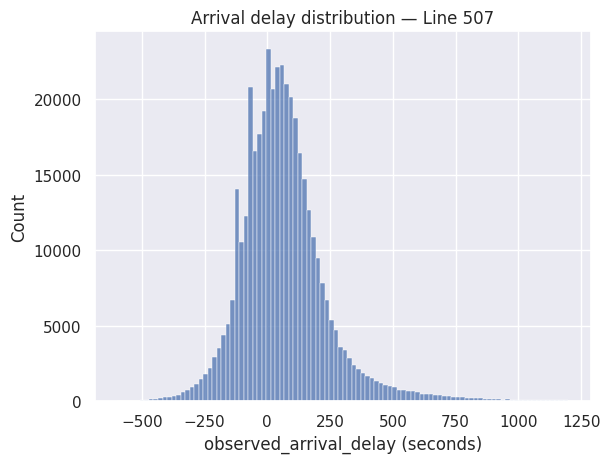

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

d = line_df['observed_arrival_delay'].dropna()
sns.histplot(x=d[(d > -600) & (d < 1200)], bins=100)
plt.title("Arrival delay distribution — Line 507")
plt.xlabel("observed_arrival_delay (seconds)")
plt.show()

In [ ]:
line_df['observed_arrival_delay'].describe()

,observed_arrival_delay
count,418313.000000
mean,71.692302
std,222.363058
min,-4870.000000
25%,-44.000000
50%,48.000000
75%,144.000000
max,6806.000000


## Section 4: Cleaning and Feature Engineering

### 4.1. Cleaning

In [6]:
clean = line_df.copy()
n0 = len(clean)

# 1. Drop missing arrival delay
clean = clean[clean['observed_arrival_delay'].notna()]
n1 = len(clean)

# 2. Drop physically impossible delays (noise)
clean = clean[(clean['observed_arrival_delay'] >= -600)]
n2 = len(clean)

print(f"Start:           {n0:,}")
print(f"After missing:   {n1:,}  (-{n0-n1:,})")
print(f"After noise:     {n2:,}  (-{n1-n2:,})")
print(f"Kept: {n2/n0*100:.1f}%")

NameError: name 'line_df' is not defined

### 4.2. Time features

In [ ]:
import numpy as np

clean['date'] = pd.to_datetime(clean['date'], format='%Y%m%d')
clean['hour'] = (clean['scheduled_arrival_time_sfm'] // 3600) % 24
clean['weekday'] = clean['date'].dt.dayofweek        # 0=Mon, 6=Sun
clean['is_weekend'] = (clean['weekday'] >= 5).astype(int)
clean['month'] = clean['date'].dt.month

def peak(h):
    if 6 <= h <= 9:   return 'morning_peak'
    if 16 <= h <= 19: return 'afternoon_peak'
    return 'off_peak'
clean['period'] = clean['hour'].apply(peak)

# Cyclical hour
clean['hour_sin'] = np.sin(2 * np.pi * clean['hour'] / 24)
clean['hour_cos'] = np.cos(2 * np.pi * clean['hour'] / 24)

### 4.3. Upstream delay features

In [ ]:
# Sort so each run is in stop order
clean = clean.sort_values(['trip_id', 'date', 'stop_sequence'])

grp = clean.groupby(['trip_id', 'date'])

# Previous row's delay and its stop_sequence
prev_delay = grp['observed_arrival_delay'].shift(1)
prev_seq   = grp['stop_sequence'].shift(1)

# Only valid if the previous row is the physically adjacent stop
is_consecutive = (clean['stop_sequence'] - prev_seq) == 1
clean['upstream_delay'] = prev_delay.where(is_consecutive)

# Same for two stops back (must be exactly 2 apart)
prev_delay_2 = grp['observed_arrival_delay'].shift(2)
prev_seq_2   = grp['stop_sequence'].shift(2)
is_consecutive_2 = (clean['stop_sequence'] - prev_seq_2) == 2
clean['upstream_delay_2'] = prev_delay_2.where(is_consecutive_2)

# Check how many valid upstream values we got
print("upstream_delay valid:",   clean['upstream_delay'].notna().sum())
print("upstream_delay NaN:",      clean['upstream_delay'].isna().sum())
print("upstream_delay_2 valid:",  clean['upstream_delay_2'].notna().sum())

upstream_delay valid: 389686
upstream_delay NaN: 28439
upstream_delay_2 valid: 361270


## Section 5: Modelling

### Train / Test Split

In [7]:
features = ['hour','weekday','is_weekend','month','hour_sin','hour_cos',
            'stop_sequence','dist_traveled','upstream_delay']
target = 'observed_arrival_delay'

model_df = clean.dropna(subset=['upstream_delay']).copy()
model_df['date'] = pd.to_datetime(model_df['date'])
model_df = model_df.sort_values(['date','trip_id','stop_sequence']).reset_index(drop=True)

train_df = model_df[model_df['date'] < '2024-10-01']
val_df   = model_df[(model_df['date'] >= '2024-10-01') & (model_df['date'] < '2024-11-01')]
test_df  = model_df[model_df['date'] >= '2024-11-01']

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (290947, 9) | Val: (34598, 9) | Test: (64141, 9)


###Model 1: Linear Regression

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"  MAE:  {mae:.1f} sec")
print(f"  RMSE: {rmse:.1f} sec")
print(f"  R2:   {r2:.3f}")

Linear Regression
  MAE:  52.7 sec
  RMSE: 81.7 sec
  R2:   0.874


###Model 2: Random Forest Regressor

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"  MAE:  {mae:.1f} sec")
print(f"  RMSE: {rmse:.1f} sec")
print(f"  R2:   {r2:.3f}")

Random Forest
  MAE:  34.3 sec
  RMSE: 67.3 sec
  R2:   0.915


GridSearch

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=3)   # respects temporal order in CV

param_grid = {'n_estimators':[100,200], 'max_depth':[None,20], 'min_samples_leaf':[1,5]}
grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=tscv, scoring='neg_mean_absolute_error', verbose=2)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}


Wider grid

In [19]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, 25],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=tscv, scoring='neg_mean_absolute_error', verbose=2)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=200; total time=  28.5s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=200; total time=  33.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=200; total time=  54.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=300; total time=  22.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=300; total time=  50.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, n_estimators=300; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=  16.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=  32.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=  54.6s
[CV] END max_depth=15, max_features=sqrt, min

In [5]:
rf_new = RandomForestRegressor(max_depth=20, max_features=1.0,
                               min_samples_leaf=10, n_estimators=300,
                               random_state=42, n_jobs=-1)
rf_new.fit(X_train, y_train)
pred = rf_new.predict(X_test)
print("New RF (wider grid)")
print(f"  MAE: {mean_absolute_error(y_test, pred):.1f}")
print(f"  R2:  {r2_score(y_test, pred):.3f}")

New RF (wider grid)
  MAE: 33.7
  R2:  0.927


Final Random Forest

In [10]:
best_rf = RandomForestRegressor(
    max_depth=20, min_samples_leaf=5, n_estimators=200,
    random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)
print("Tuned Random Forest")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf):.1f} sec")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.1f} sec")
print(f"  R2:   {r2_score(y_test, y_pred_rf):.3f}")

# Save
import joblib
joblib.dump(best_rf, f"{ALERTS_PATH}/rf_model_temporal.pkl")
print("Saved")

Tuned Random Forest
  MAE:  33.1 sec
  RMSE: 62.1 sec
  R2:   0.928
Saved


### Model 3: XGBoost

In [6]:
import xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                   random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
print("XGBoost")
print(f"  MAE: {mean_absolute_error(y_test, pred):.1f}")
print(f"  R2:  {r2_score(y_test, pred):.3f}")

XGBoost
  MAE: 38.1
  R2:  0.818


GridSearch

In [7]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=tscv, scoring='neg_mean_absolute_error', verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best CV MAE: 36.47070755271912


In [8]:
xgb_best = XGBRegressor(learning_rate=0.05, max_depth=6, n_estimators=300,
                        subsample=0.8, random_state=42, n_jobs=-1)
xgb_best.fit(X_train, y_train)

pred = xgb_best.predict(X_test)
print("XGBoost (tuned)")
print(f"  MAE: {mean_absolute_error(y_test, pred):.1f}")
print(f"  R2:  {r2_score(y_test, pred):.3f}")

XGBoost (tuned)
  MAE: 39.8
  R2:  0.816


###Model 4: Neural Network

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaled:", X_train_s.shape)

Scaled: (290947, 9)


### Size 512x512

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1)
])

model_nn.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_nn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,289 (1.02 MB)

 Trainable params: 268,289 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Train and evaluate

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=15, restore_best_weights=True)

history = model_nn.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 47.5301 - mae: 47.5301 - val_loss: 48.3706 - val_mae: 48.3706
Epoch 2/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 40.5538 - mae: 40.5538 - val_loss: 47.5604 - val_mae: 47.5604
Epoch 3/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 40.1026 - mae: 40.1026 - val_loss: 47.1477 - val_mae: 47.1477
Epoch 4/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 39.7272 - mae: 39.7272 - val_loss: 47.0671 - val_mae: 47.0671
Epoch 5/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 39.3375 - mae: 39.3375 - val_loss: 46.7618 - val_mae: 46.7618
Epoch 6/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 38.8830 - mae: 38.8830 - val_loss: 46.5646 - val_mae: 46.5646
Epoch 7/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 38.3858 - mae: 38.3858 - val_loss: 46.3365 - val_mae: 46.3365
Epoch 8/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 37.8233 - mae: 37.8233 - val_loss: 45.8231 - val_mae: 45.8231


In [20]:
y_pred_nn = model_nn.predict(X_test_s).flatten()
print("Neural Network")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_nn):.1f} sec")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_nn)):.1f} sec")
print(f"  R2:   {r2_score(y_test, y_pred_nn):.3f}")

2005/2005 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Neural Network
  MAE:  69.0 sec
  RMSE: 95.4 sec
  R2:   0.829


In [21]:
model_nn.save(f"{ALERTS_PATH}/nn_model_512.keras")
print("NN 512 saved")

NN 512 saved


### Size 256x256

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1)
])

model_nn.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_nn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,609 (268.00 KB)

 Trainable params: 68,609 (268.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=15, restore_best_weights=True)

history = model_nn.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

model_nn.save(f"{ALERTS_PATH}/nn_model_256.keras")
print("NN 256 saved")

Epoch 1/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 46.0871 - mae: 46.0871 - val_loss: 47.2468 - val_mae: 47.2468
Epoch 2/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 40.3312 - mae: 40.3312 - val_loss: 46.6809 - val_mae: 46.6809
Epoch 3/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 39.9786 - mae: 39.9786 - val_loss: 46.5511 - val_mae: 46.5511
Epoch 4/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 39.6582 - mae: 39.6582 - val_loss: 46.5278 - val_mae: 46.5278
Epoch 5/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 39.2948 - mae: 39.2948 - val_loss: 46.5372 - val_mae: 46.5372
Epoch 6/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 38.9042 - mae: 38.9042 - val_loss: 46.4434 - val_mae: 46.4434
Epoch 7/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 38.4508 - mae: 38.4508 - val_loss: 46.1429 - val_mae: 46.1429
Epoch 8/300
910/910 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 37.9395 - mae: 37.9395 - val_loss: 46.0054 - val_mae: 46.0054
Epoch 9/300
91

In [26]:
y_pred_nn = model_nn_256.predict(X_test_s).flatten()
print("Neural Network")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_nn):.1f} sec")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_nn)):.1f} sec")
print(f"  R2:   {r2_score(y_test, y_pred_nn):.3f}")

2005/2005 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Neural Network
  MAE:  51.0 sec
  RMSE: 78.6 sec
  R2:   0.884


Dropout

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)
model_drop = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),                      # drops 30% of neurons each step
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1)
])
model_drop.compile(optimizer='adam', loss='mae', metrics=['mae'])

es = keras.callbacks.EarlyStopping(monitor='val_mae', patience=15, restore_best_weights=True)
model_drop.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
               epochs=300, batch_size=256, callbacks=[es], verbose=1)


Epoch 1/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 53.7303 - mae: 53.7303 - val_loss: 51.5224 - val_mae: 51.5224
Epoch 2/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 44.7590 - mae: 44.7590 - val_loss: 50.8230 - val_mae: 50.8230
Epoch 3/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 44.1285 - mae: 44.1285 - val_loss: 50.6014 - val_mae: 50.6014
Epoch 4/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 43.8012 - mae: 43.8012 - val_loss: 50.1410 - val_mae: 50.1410
Epoch 5/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 43.4813 - mae: 43.4813 - val_loss: 49.5984 - val_mae: 49.5984
Epoch 6/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 43.1578 - mae: 43.1578 - val_loss: 49.1530 - val_mae: 49.1530
Epoch 7/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 42.7766 - mae: 42.7766 - val_loss: 48.8459 - val_mae: 48.8459
Epoch 8/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 42.3444 - mae: 42.3444 - val_loss: 48.5538 - v

In [14]:
y_pred = model_drop.predict(X_test_s).flatten()
print("NN 256 + dropout 0.3")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.1f}")
print(f"  R2:  {r2_score(y_test, y_pred):.3f}")

2005/2005 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
NN 256 + dropout 0.3
  MAE: 68.0
  R2:  0.835


### Size 128*64

In [27]:
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)
model_128 = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model_128.compile(optimizer='adam', loss='mae', metrics=['mae'])

es = keras.callbacks.EarlyStopping(monitor='val_mae', patience=15, restore_best_weights=True)
model_128.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=300, batch_size=256, callbacks=[es], verbose=1)

y_pred = model_128.predict(X_test_s).flatten()
print("NN 128-64")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.1f}")
print(f"  R2:  {r2_score(y_test, y_pred):.3f}")

Epoch 1/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 56.2809 - mae: 56.2809 - val_loss: 51.5139 - val_mae: 51.5139
Epoch 2/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 42.4421 - mae: 42.4421 - val_loss: 51.0451 - val_mae: 51.0451
Epoch 3/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.9484 - mae: 41.9484 - val_loss: 50.4527 - val_mae: 50.4527
Epoch 4/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.5780 - mae: 41.5780 - val_loss: 50.1161 - val_mae: 50.1161
Epoch 5/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 41.2975 - mae: 41.2975 - val_loss: 49.9938 - val_mae: 49.9938
Epoch 6/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.0515 - mae: 41.0515 - val_loss: 49.7255 - val_mae: 49.7255
Epoch 7/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40.8408 - mae: 40.8408 - val_loss: 49.6000 - val_mae: 49.6000
Epoch 8/300
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40.6463 - mae: 40.6463 - val_loss: 49.4635 - val_mae: 49.4635

### Results

In [12]:
import numpy as np

def evaluate(name, y_true, y_pred):
    print(f"{name:20s} MAE {mean_absolute_error(y_true,y_pred):5.1f} | "
          f"RMSE {np.sqrt(mean_squared_error(y_true,y_pred)):5.1f} | "
          f"R2 {r2_score(y_true,y_pred):.3f}")

# All models on the same test set
evaluate("Linear Regression", y_test, lr.predict(X_test))
evaluate("Random Forest",     y_test, best_rf.predict(X_test))
evaluate("XGBoost",           y_test, xgb_best.predict(X_test))
evaluate("Neural Net 256",    y_test, model_nn_256.predict(X_test_s).flatten())

Linear Regression    MAE  52.7 | RMSE  81.7 | R2 0.874
Random Forest        MAE  33.1 | RMSE  62.1 | R2 0.928
XGBoost              MAE  39.8 | RMSE  99.0 | R2 0.816
2005/2005 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Neural Net 256       MAE  54.2 | RMSE  81.5 | R2 0.875


## Section 6: Anomaly detection

An anomaly is a stop event whose actual delay deviates strongly from the model's predicted delay.
We compute residuals (actual - predicted) for both
the Random Forest and the Neural Network, flag large residuals as anomalies,
and later validate them against the reconstructed ServiceAlert incidents.

### Compute residuals for both models

In [ ]:
# anomalies across all events and validate them against alerts.
X_all = model_df[features]
X_all_scaled = scaler.transform(X_all)

# Random Forest residuals
pred_rf = best_rf.predict(X_all)
model_df['pred_rf'] = pred_rf
model_df['resid_rf'] = model_df['observed_arrival_delay'] - pred_rf

# Neural Network residuals
pred_nn = model_nn.predict(X_all_scaled).flatten()
model_df['pred_nn'] = pred_nn
model_df['resid_nn'] = model_df['observed_arrival_delay'] - pred_nn

print(model_df[['observed_arrival_delay','pred_rf','resid_rf',
                'pred_nn','resid_nn']].head())

12178/12178 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step
   observed_arrival_delay    pred_rf   resid_rf    pred_nn   resid_nn
1                   -19.0 -58.951523  39.951523 -81.272949  62.272949
3                   -12.0 -70.139279  58.139279 -81.713043  69.713043
5                   102.0  48.559973  53.440027   5.958189  96.041811
7                    -6.0 -25.717567  19.717567 -36.287865  30.287865
9                   -19.0 -62.022117  43.022117 -97.142159  78.142159


Residual distribution

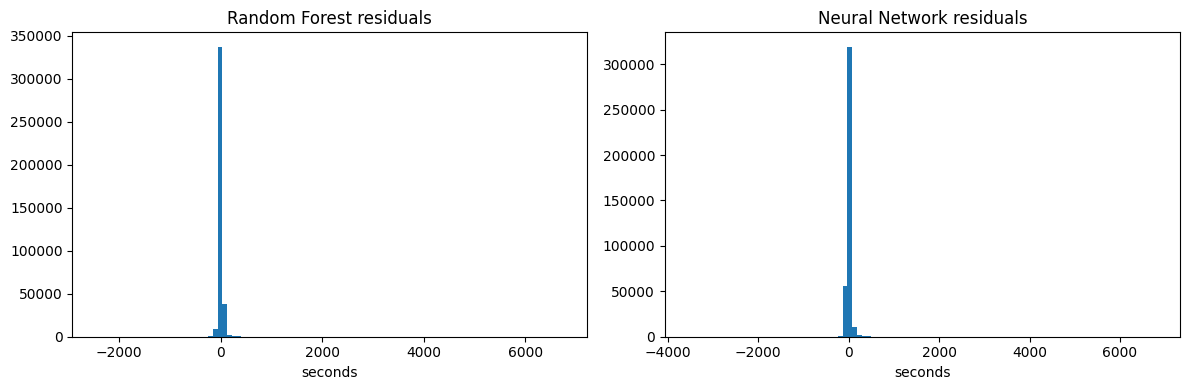

RF residual: mean -0.2, std 56.7
NN residual: mean 5.4, std 66.0


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(model_df['resid_rf'], bins=100)
axes[0].set_title("Random Forest residuals"); axes[0].set_xlabel("seconds")
axes[1].hist(model_df['resid_nn'], bins=100)
axes[1].set_title("Neural Network residuals"); axes[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

print("RF residual: mean {:.1f}, std {:.1f}".format(
    model_df['resid_rf'].mean(), model_df['resid_rf'].std()))
print("NN residual: mean {:.1f}, std {:.1f}".format(
    model_df['resid_nn'].mean(), model_df['resid_nn'].std()))

Flag anomalies

In [ ]:
for m in ['rf', 'nn']:
    r = model_df[f'resid_{m}']
    z = (r - r.mean()) / r.std()
    model_df[f'anomaly_{m}'] = (z.abs() > 3).astype(int)

print("RF anomalies:", model_df['anomaly_rf'].sum(),
      f"({model_df['anomaly_rf'].mean()*100:.2f}%)")
print("NN anomalies:", model_df['anomaly_nn'].sum(),
      f"({model_df['anomaly_nn'].mean()*100:.2f}%)")

# Agreement between the two models
both = ((model_df['anomaly_rf']==1) & (model_df['anomaly_nn']==1)).sum()
print("Flagged by both models:", both)

RF anomalies: 3519 (0.90%)
NN anomalies: 3177 (0.82%)
Flagged by both models: 2603


Cluster analysis

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Only the consensus anomalies
anom = model_df[(model_df['anomaly_rf']==1) & (model_df['anomaly_nn']==1)].copy()

# Variables that describe the TYPE of anomaly
char_features = ['resid_rf', 'upstream_delay', 'stop_sequence', 'observed_arrival_delay']
X_anom = StandardScaler().fit_transform(anom[char_features])

km = KMeans(n_clusters=4, random_state=42, n_init=10)
anom['type'] = km.fit_predict(X_anom)

# Describe each anomaly type
print(anom.groupby('type')[char_features].mean().round(1))
print("\nSize of each type:")
print(anom['type'].value_counts())

      resid_rf  upstream_delay  stop_sequence  observed_arrival_delay
type                                                                 
0       1173.9            41.2           13.2                  1456.3
1        235.2          1161.3           10.4                  1448.1
2        225.6           -75.4           14.4                   251.8
3        260.1            93.6            4.9                   408.7

Size of each type:
type
2    1474
3     684
0     317
1     128
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

anom = model_df[(model_df['anomaly_rf']==1) & (model_df['anomaly_nn']==1)].copy()

char_features = ['resid_rf', 'upstream_delay', 'stop_sequence', 'observed_arrival_delay']
X_anom = StandardScaler().fit_transform(anom[char_features])

db = DBSCAN(eps=1.0, min_samples=10)
anom['db_label'] = db.fit_predict(X_anom)

n_noise = (anom['db_label'] == -1).sum()
n_clusters = len(set(anom['db_label'])) - (1 if -1 in anom['db_label'].values else 0)
print(f"Clusters: {n_clusters}")
print(f"Noise points (isolated anomalies): {n_noise} ({n_noise/len(anom)*100:.1f}%)")

Clusters: 1
Noise points (isolated anomalies): 42 (1.6%)


In [ ]:
# Rebuild incidents and the matching function
inc = route_incidents[route_incidents['route_id'] == LINE_ID].copy()
inc['start'] = pd.to_datetime(inc['start'])
inc['end'] = pd.to_datetime(inc['end'])

TOL = pd.Timedelta(minutes=30)
def in_any_incident(ts):
    return len(inc[(inc['start'] - TOL <= ts) & (ts <= inc['end'] + TOL)]) > 0

print("Incidents ready:", len(inc))

Incidents ready: 38


In [ ]:
noise = anom[anom['db_label'] == -1].copy()
noise['date'] = pd.to_datetime(noise['date'])
noise['timestamp'] = noise['date'] + pd.to_timedelta(
    noise['scheduled_arrival_time_sfm'], unit='s')
noise['matched'] = noise['timestamp'].apply(in_any_incident)

print("Noise points:", len(noise))
print("Matched a real incident:", noise['matched'].sum())
print()
print(noise[['date','stop_sequence','observed_arrival_delay',
             'upstream_delay','resid_rf','matched']]
      .sort_values('resid_rf', ascending=False).to_string(index=False))

Noise points: 42
Matched a real incident: 16

      date  stop_sequence  observed_arrival_delay  upstream_delay     resid_rf  matched
2024-08-20              2                  6716.0           -60.0  6768.988380    False
2024-06-05             11                  5391.0           410.0  4454.374057    False
2024-08-20              2                  3995.0           -60.0  3597.881621    False
2024-11-14              3                  3491.0            -3.0  3495.113727    False
2024-11-05              2                  3461.0           -60.0  3100.980553    False
2024-09-22              2                  3183.0           -60.0  2843.177640    False
2024-05-07              7                  5136.0          1904.0  2653.327805     True
2024-09-12              2                  3774.0           716.0  2588.660888    False
2024-12-27              2                  2945.0           278.0  2331.275865    False
2024-08-26              5                  6005.0          3406.0  2236.39

## Section 7: Validation against ServiceAlerts

### Prepare incidents for line 507

In [ ]:
LINE_507 = '9011001050700000'

inc = route_incidents[route_incidents['route_id'] == LINE_507].copy()
inc['start'] = pd.to_datetime(inc['start'])
inc['end'] = pd.to_datetime(inc['end'])

print("Incidents on line 507:", len(inc))
print("Date range:", inc['start'].min(), "→", inc['start'].max())

Incidents on line 507: 38
Date range: 2024-01-12 06:48:25 → 2024-10-02 17:22:39


In [ ]:
# Timestamp of each anomaly event = service date + scheduled arrival time
def add_timestamp(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['timestamp'] = df['date'] + pd.to_timedelta(
        df['scheduled_arrival_time_sfm'], unit='s')
    return df

model_df = add_timestamp(model_df)

### Match anomalies to incidents

In [ ]:
TOL = pd.Timedelta(minutes=30)

def in_any_incident(ts):
    hit = inc[(inc['start'] - TOL <= ts) & (ts <= inc['end'] + TOL)]
    return len(hit) > 0

def incident_detected(row, anomalies):
    lo, hi = row['start'] - TOL, row['end'] + TOL
    return ((anomalies['timestamp'] >= lo) & (anomalies['timestamp'] <= hi)).any()

for m in ['rf', 'nn']:
    anomalies = model_df[model_df[f'anomaly_{m}'] == 1]
    # Precision
    matched = anomalies['timestamp'].apply(in_any_incident)
    # Coverage
    detected = inc.apply(lambda r: incident_detected(r, anomalies), axis=1)
    print(f"{m.upper()}: {len(anomalies)} anomalies | "
          f"precision {matched.mean()*100:.1f}% | "
          f"coverage {detected.sum()}/{len(inc)} ({detected.mean()*100:.1f}%)")

RF: 3519 anomalies | precision 15.3% | coverage 36/38 (94.7%)
NN: 3177 anomalies | precision 16.2% | coverage 36/38 (94.7%)


### Early detection gap

In [ ]:
anomalies_rf = model_df[model_df['anomaly_rf'] == 1]

gaps = []
for _, row in inc.iterrows():
    lo = row['start'] - TOL
    hi = row['end'] + TOL
    hits = anomalies_rf[(anomalies_rf['timestamp'] >= lo) &
                        (anomalies_rf['timestamp'] <= hi)]
    if len(hits) > 0:
        first_anom = hits['timestamp'].min()
        gap_min = (first_anom - row['start']).total_seconds() / 60
        gaps.append(gap_min)

gaps = pd.Series(gaps)
print("Detected incidents with an anomaly:", len(gaps))
print(f"Anomaly appears before alert (gap<0): {(gaps<0).sum()} of {len(gaps)}")
print(f"Median gap: {gaps.median():.1f} min "
      "(negative = anomaly precedes the official alert)")

NameError: name 'model_df' is not defined

### Validation results
- Coverage: 36/38 incidents detected (94.7%) by both models.
- Precision: ~15% (expected — only 38 recorded incidents vs ~3,500 anomalies;
  most anomalies have no matching alert, likely unreported disruptions or noise).
- Early detection: 27/36 detected incidents were flagged before the official
  alert, median 14 min earlier. Note: this is earlier than the official *report*,
  not necessarily earlier than the disruption's onset.
- The 2 missed incidents had no anomaly within their time window (short
  morning incidents with no stop specified).

Physical-coherence check: 88% of anomalies persist at the consecutive stop
(consistent with real disruptions); 12% are isolated peaks (candidate artifacts).

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# DBSCAN on the residual (1D) — dense normal residuals vs. isolated anomalies
res = model_df['resid_rf'].values.reshape(-1, 1)

db = DBSCAN(eps=20, min_samples=50)   # eps in seconds; tune below
model_df['resid_db'] = db.fit_predict(res)

n_out = (model_df['resid_db'] == -1).sum()
print(f"Outliers (anomalies): {n_out} ({n_out/len(model_df)*100:.2f}%)")
print(f"Clusters: {len(set(model_df['resid_db'])) - (1 if -1 in model_df['resid_db'].values else 0)}")

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Average residual of both models (consensus signal)
model_df['resid_avg'] = (model_df['resid_rf'].abs() + model_df['resid_nn'].abs()) / 2

res = model_df['resid_avg'].values.reshape(-1, 1)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df['resid_cluster'] = km.fit_predict(res)

summary = model_df.groupby('resid_cluster')['resid_avg'].agg(
    count='count', mean_val='mean')
print(summary.sort_values('mean_val'))

## Aditional exploring

In [ ]:
# 1. Parse weather timestamp and round to the hour
weather['Tidpunkt'] = pd.to_datetime(weather['Tidpunkt'], utc=True).dt.tz_localize(None)
weather['hour_key'] = weather['Tidpunkt'].dt.floor('h')

# Rename
weather = weather.rename(columns={
    'Nederbörd (mm)': 'precip',
    'Temperatur (°C)': 'temp',
    'Vindhastighet (m/s)': 'wind'
})
weather_small = weather[['hour_key', 'precip', 'temp', 'wind']]

# 2. Build the same hourly key on events
model_df['hour_key'] = model_df['timestamp'].dt.floor('h')

# 3. Merge weather into events by the hour
model_df = model_df.merge(weather_small, on='hour_key', how='left')

# 4. Check the merge worked
print("Events with weather:", model_df['temp'].notna().sum(), "of", len(model_df))
print(model_df[['timestamp','temp','precip','wind','observed_arrival_delay']].head())

Events with weather: 389563 of 389686
            timestamp  temp  precip  wind  observed_arrival_delay
0 2024-06-24 18:27:00  19.8     0.0   3.2                   -19.0
1 2024-06-25 18:27:00  22.4     0.0   4.4                   -12.0
2 2024-06-26 18:27:00  24.7     0.0   3.0                   102.0
3 2024-06-28 18:27:00  20.4     0.0   2.5                    -6.0
4 2024-07-01 18:27:00  20.3     0.0   5.0                   -19.0


In [ ]:
wcorr = model_df[['observed_arrival_delay','temp','precip','wind',
                  'upstream_delay']].corr()
print(wcorr['observed_arrival_delay'].sort_values(ascending=False))

observed_arrival_delay    1.000000
upstream_delay            0.918613
wind                      0.033822
precip                    0.011256
temp                     -0.029157
Name: observed_arrival_delay, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression

df_w = model_df.dropna(subset=['temp','precip','wind','upstream_delay']).copy()

base_features = ['hour','weekday','is_weekend','month','hour_sin','hour_cos',
                 'stop_sequence','dist_traveled','upstream_delay']
weather_features = base_features + ['temp','precip','wind']

y_w = df_w['observed_arrival_delay']

def quick_lr(feat_list, label):
    Xtr, Xte, ytr, yte = train_test_split(df_w[feat_list], y_w,
                                          test_size=0.2, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    p = m.predict(Xte)
    print(f"{label}: MAE {mean_absolute_error(yte,p):.1f} | R2 {r2_score(yte,p):.3f}")

quick_lr(base_features, "Without weather")
quick_lr(weather_features, "With weather   ")

Without weather: MAE 48.3 | R2 0.843
With weather   : MAE 48.3 | R2 0.843


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Add upstream_delay_2 (already created in Section 4) and compare
df2 = model_df.dropna(subset=['upstream_delay','upstream_delay_2']).copy()

feats_base = ['hour','weekday','is_weekend','month','hour_sin','hour_cos',
              'stop_sequence','dist_traveled','upstream_delay']
feats_plus = feats_base + ['upstream_delay_2']

y2 = df2['observed_arrival_delay']

def quick_lr(feat, label):
    Xtr,Xte,ytr,yte = train_test_split(df2[feat], y2, test_size=0.2, random_state=42)
    m = LinearRegression().fit(Xtr,ytr)
    p = m.predict(Xte)
    print(f"{label}: MAE {mean_absolute_error(yte,p):.1f} | R2 {r2_score(yte,p):.3f}")

quick_lr(feats_base, "1 upstream ")
quick_lr(feats_plus, "2 upstreams")

1 upstream : MAE 45.9 | R2 0.860
2 upstreams: MAE 45.9 | R2 0.860


             mean  median  count
month                           
1      159.313013   126.0  30938
2      115.521835   102.0  32792
3       83.055530    74.0  32253
4       87.450384    73.0  29799
5      115.392826    79.0  34178
6       99.490333    64.0  33153
7       31.738659    31.0  31105
8      104.166197    69.0  33707
9       37.211768    13.0  33022
10      48.657148    14.0  34598
11      36.439327     7.0  32527
12      26.571139     0.0  31614


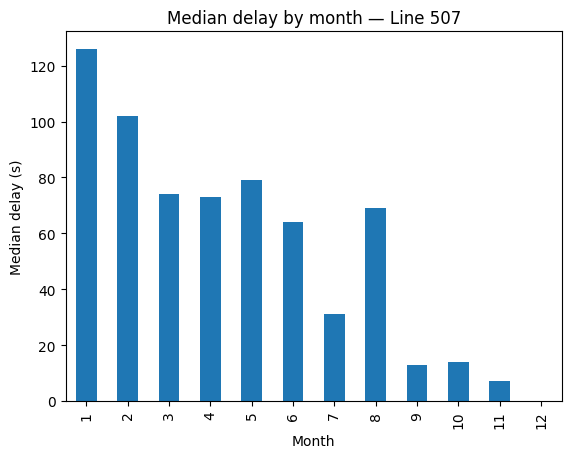

In [ ]:
# Retraso promedio y mediano por mes
model_df['month'] = pd.to_datetime(model_df['date']).dt.month
monthly = model_df.groupby('month')['observed_arrival_delay'].agg(['mean','median','count'])
print(monthly)

# Gráfico
monthly['median'].plot(kind='bar')
plt.ylabel("Median delay (s)")
plt.xlabel("Month")
plt.title("Median delay by month — Line 507")
plt.show()

In [ ]:
anom = model_df[model_df['anomaly_rf'] == 1].copy()
anom['month'] = pd.to_datetime(anom['date']).dt.month

# Anomalías por mes vs. eventos por mes (para ver la TASA, no solo el conteo)
anom_rate = (anom.groupby('month').size() /
             model_df.groupby('month').size() * 100).round(2)
print("Tasa de anomalías por mes (%):")
print(anom_rate)

Tasa de anomalías por mes (%):
month
1     0.89
2     0.74
3     0.60
4     0.71
5     1.46
6     1.41
7     0.95
8     0.98
9     1.00
10    0.81
11    0.60
12    0.64
dtype: float64


Aditional

In [ ]:
# Use consensus anomalies: flagged by BOTH models (more robust)
anom = model_df[(model_df['anomaly_rf'] == 1) & (model_df['anomaly_nn'] == 1)].copy()
anom = anom.sort_values(['trip_id','date','stop_sequence'])

# A new episode starts when trip/day changes, or the stop sequence is not consecutive
anom['new_episode'] = (
    (anom['trip_id'] != anom['trip_id'].shift()) |
    (anom['date'] != anom['date'].shift()) |
    (anom['stop_sequence'] != anom['stop_sequence'].shift() + 1)
)
anom['episode_id'] = anom['new_episode'].cumsum()

n_events = len(anom)
n_episodes = anom['episode_id'].nunique()

print(f"Individual anomalies (stop events): {n_events}")
print(f"Distinct episodes (disruptions):    {n_episodes}")
print(f"Avg stops per episode: {n_events/n_episodes:.1f}")

print("\nEpisode size (number of stops affected):")
print(anom.groupby('episode_id').size().value_counts().sort_index())

Individual anomalies (stop events): 2603
Distinct episodes (disruptions):    2533
Avg stops per episode: 1.0

Episode size (number of stops affected):
1    2471
2      54
3       8
Name: count, dtype: int64


In [ ]:
anom = model_df[(model_df['anomaly_rf'] == 1) & (model_df['anomaly_nn'] == 1)].copy()
anom = anom.sort_values(['trip_id','date','stop_sequence'])

# For consecutive anomalies in the same trip+day, what's the gap in stop_sequence?
same = (anom['trip_id'] == anom['trip_id'].shift()) & (anom['date'] == anom['date'].shift())
gap = (anom['stop_sequence'] - anom['stop_sequence'].shift())[same]

print("Gaps between consecutive anomalies (same trip+day):")
print(gap.value_counts().sort_index().head(15))

Gaps between consecutive anomalies (same trip+day):
stop_sequence
1.0     70
2.0     23
3.0     33
4.0      9
5.0     19
6.0     14
7.0     13
8.0     12
9.0     18
10.0     1
11.0     2
12.0     1
13.0     7
14.0     6
15.0     1
Name: count, dtype: int64
